In [1]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    dbname='postgres',
    user='postgres',
    host='localhost',
    password=input()
)

cur = conn.cursor

query = """SELECT  t.issuer_id || ' - ' || t2.issuer_name AS Issuer_Title,
        COUNT(t.*) AS total_new_issuances,
        ROUND(AVG(CASE WHEN t.original_principal_balance <>'NaN'THEN CAST(t.original_principal_balance AS NUMERIC) ELSE NULL END), 2) As Average_OPB,
        SUM(CASE WHEN t.original_principal_balance <>'NaN'THEN CAST(t.original_principal_balance AS NUMERIC) ELSE NULL END) AS Total_OPB,
        ROUND(AVG(CASE WHEN t.loan_interest_rate <>'NaN'THEN CAST(t.loan_interest_rate AS NUMERIC) ELSE NULL END), 2)AS Average_interest_rate,
        ROUND(AVG(CASE WHEN t.credit_score <>'NaN'THEN CAST(t.credit_score AS NUMERIC) ELSE NULL END)) As Average_credit_Score,
        SUM(CASE WHEN t.agency = 'F' THEN 1 ELSE 0 END) AS New_FHA_Issuances,
        SUM(CASE WHEN t.agency = 'V' THEN 1 ELSE 0 END) AS New_VA_Issuances,
        SUM(CASE WHEN t.agency = 'R' THEN 1 ELSE 0 END) AS New_RD_Issuances,
        SUM(CASE WHEN t.agency = 'N' THEN 1 ELSE 0 END) AS New_PIH_Issuances,
        as_of_date
FROM sf_new_issuance_loan_level t
JOIN issuer_info t2 ON t.issuer_id = t2.issuer_number
GROUP BY t.issuer_id || ' - ' || t2.issuer_name, as_of_date"""

df = pd.read_sql(query, conn)

conn.close()

print(df.head())

C:\Users\H59045\AppData\Local\Temp\1\ipykernel_5652\3817643313.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


                           issuer_title  total_new_issuances  average_opb  \
0     1555 - Guild Mortgage Company LLC                 2011    329698.16   
1  1699 - Standard Mortgage Corporation                   62    202580.65   
2                 1857 - Bank of Hawaii                    2    640000.00   
3                1909 - 1st Source Bank                    1    196000.00   
4            1977 - Pulte Mortgage, LLC                  250    402280.00   

     total_opb  average_interest_rate  average_credit_score  \
0  663023000.0                   6.23                 684.0   
1   12560000.0                   6.10                 702.0   
2    1280000.0                   5.75                 746.0   
3     196000.0                   6.50                 698.0   
4  100570000.0                   4.79                 695.0   

   new_fha_issuances  new_va_issuances  new_rd_issuances  new_pih_issuances  \
0               1281               595               121                 14   


(array([0, 1, 2, 3]),
 [Text(0, 0, 'FHA'), Text(1, 0, 'VA'), Text(2, 0, 'RD'), Text(3, 0, 'PIH')])

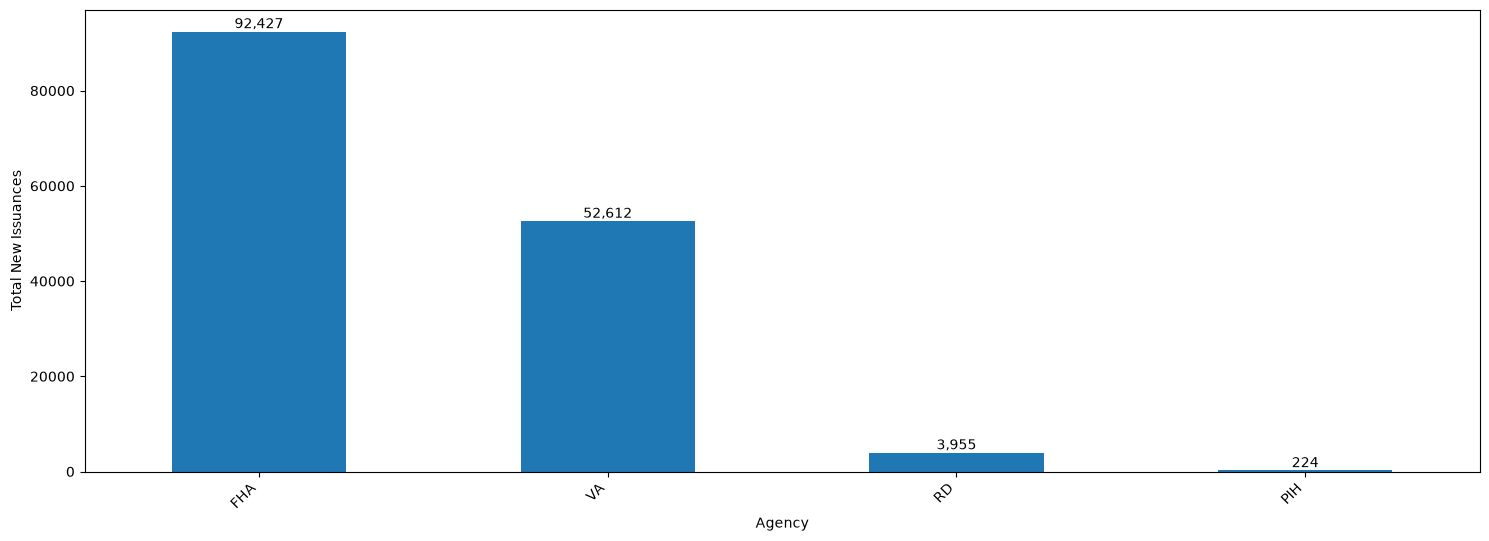

In [2]:
agencies = {'new_fha_issuances': 'FHA',
            'new_va_issuances': 'VA',
            'new_rd_issuances': 'RD',
            'new_pih_issuances': 'PIH'}

totals = df[list(agencies.keys())].sum()
totals.index = totals.index.map(agencies)
ax = totals.plot(kind='bar', figsize=(18,6))

labels = [f'{int(v):,}' for v in totals.values]
ax.bar_label(ax.containers[0], labels=labels)
plt.xlabel('Agency')
plt.ylabel('Total New Issuances')
plt.xticks(rotation=45, ha='right')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '4094 - PennyMac Loan Services, LLC'),
  Text(1, 0, '3725 - United Wholesale Mortgages, LLC'),
  Text(2, 0, '3871 - Freedom Home Mortgage Corporation'),
  Text(3, 0, '4042 - Rocket Mortgage, LLC'),
  Text(4, 0, '4150 - Lakeview Loan Servicing, LLC'),
  Text(5, 0, '4135 - Planet Home Lending, LLC'),
  Text(6, 0, '4206 - NewRez LLC'),
  Text(7, 0, '3359 - Amerihome Mortgage Company, LLC'),
  Text(8, 0, '4058 - Village Capital & Investment, LLC'),
  Text(9, 0, '2397 - Onity Mortgage Corporation')])

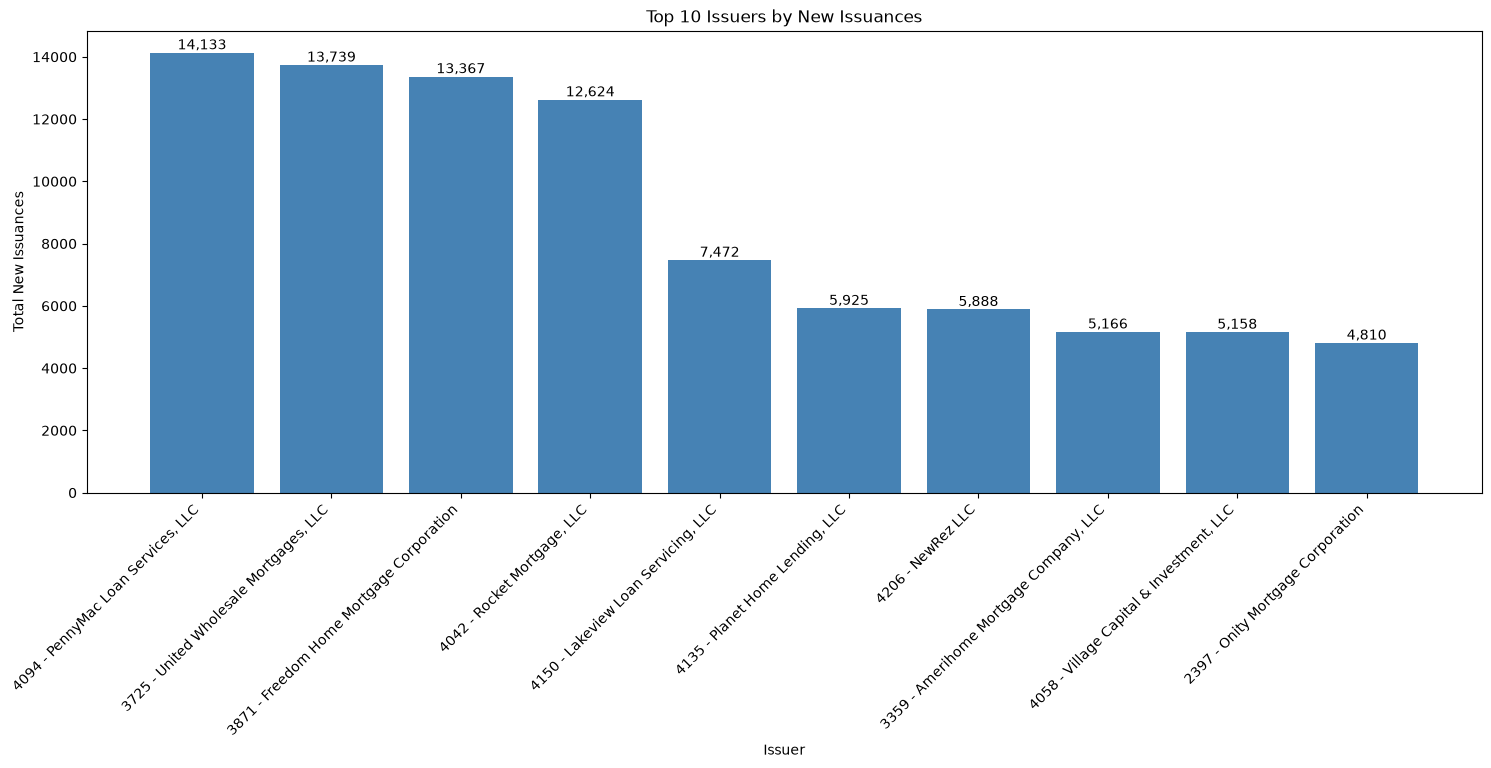

In [3]:
top_issuers = df.nlargest(10,'total_new_issuances')

plt.figure(figsize=(18,6))
bars = plt.bar(top_issuers['issuer_title'], top_issuers['total_new_issuances'], color='steelblue',)
plt.bar_label(bars, fmt=lambda x: f'{int(x):,}')
plt.title('Top 10 Issuers by New Issuances')
plt.xlabel('Issuer')
plt.ylabel('Total New Issuances')
plt.xticks(rotation=45, ha='right')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '4094 - PennyMac Loan Services, LLC'),
  Text(1, 0, '3725 - United Wholesale Mortgages, LLC'),
  Text(2, 0, '3871 - Freedom Home Mortgage Corporation'),
  Text(3, 0, '4042 - Rocket Mortgage, LLC'),
  Text(4, 0, '4150 - Lakeview Loan Servicing, LLC'),
  Text(5, 0, '4135 - Planet Home Lending, LLC'),
  Text(6, 0, '4206 - NewRez LLC'),
  Text(7, 0, '3359 - Amerihome Mortgage Company, LLC'),
  Text(8, 0, '4058 - Village Capital & Investment, LLC'),
  Text(9, 0, '2397 - Onity Mortgage Corporation')])

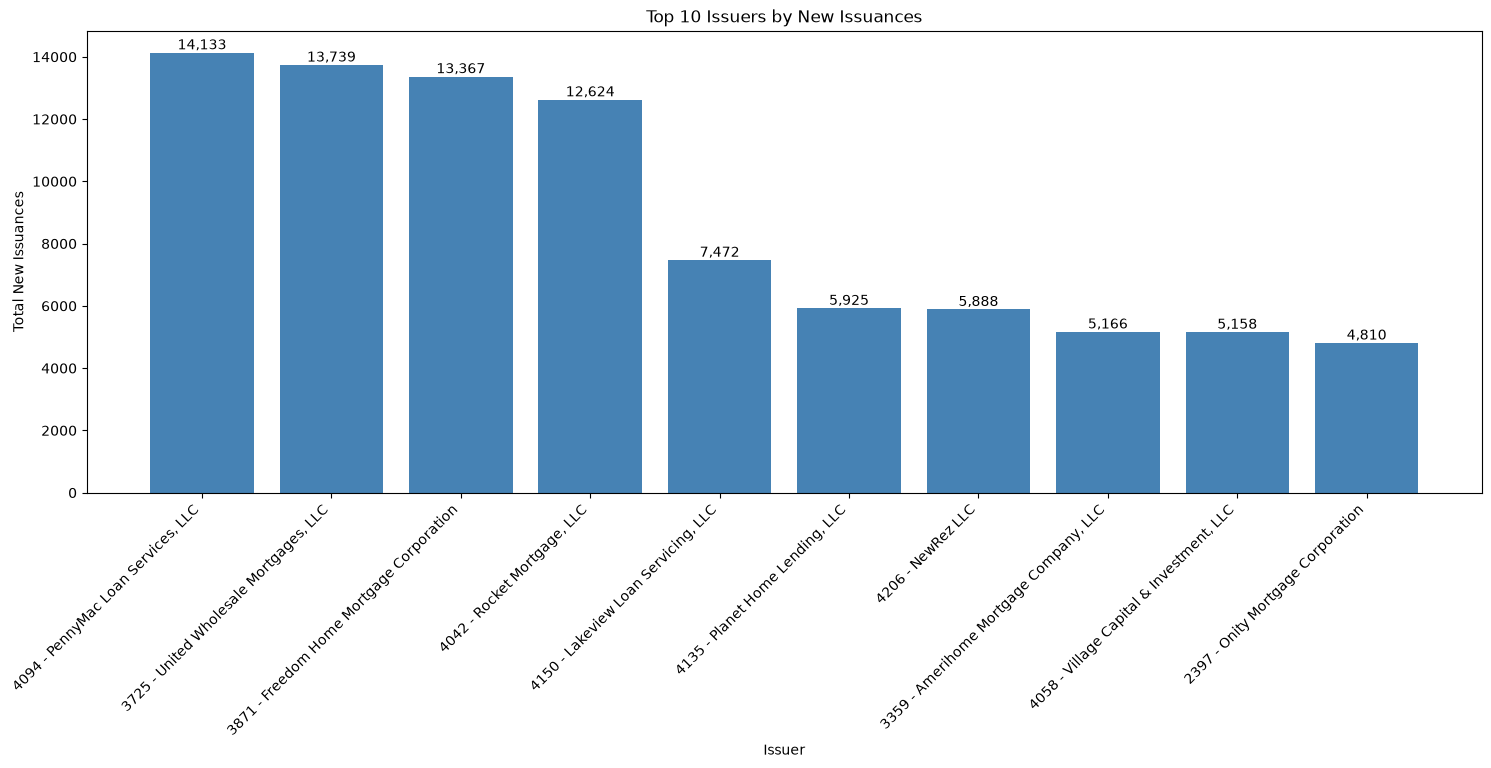

In [4]:
top_states = df.nlargest(10,'total_new_issuances')

plt.figure(figsize=(18,6))
bars = plt.bar(top_issuers['issuer_title'], top_issuers['total_new_issuances'], color='steelblue',)
plt.bar_label(bars, fmt=lambda x: f'{int(x):,}')
plt.title('Top 10 Issuers by New Issuances')
plt.xlabel('Issuer')
plt.ylabel('Total New Issuances')
plt.xticks(rotation=45, ha='right')